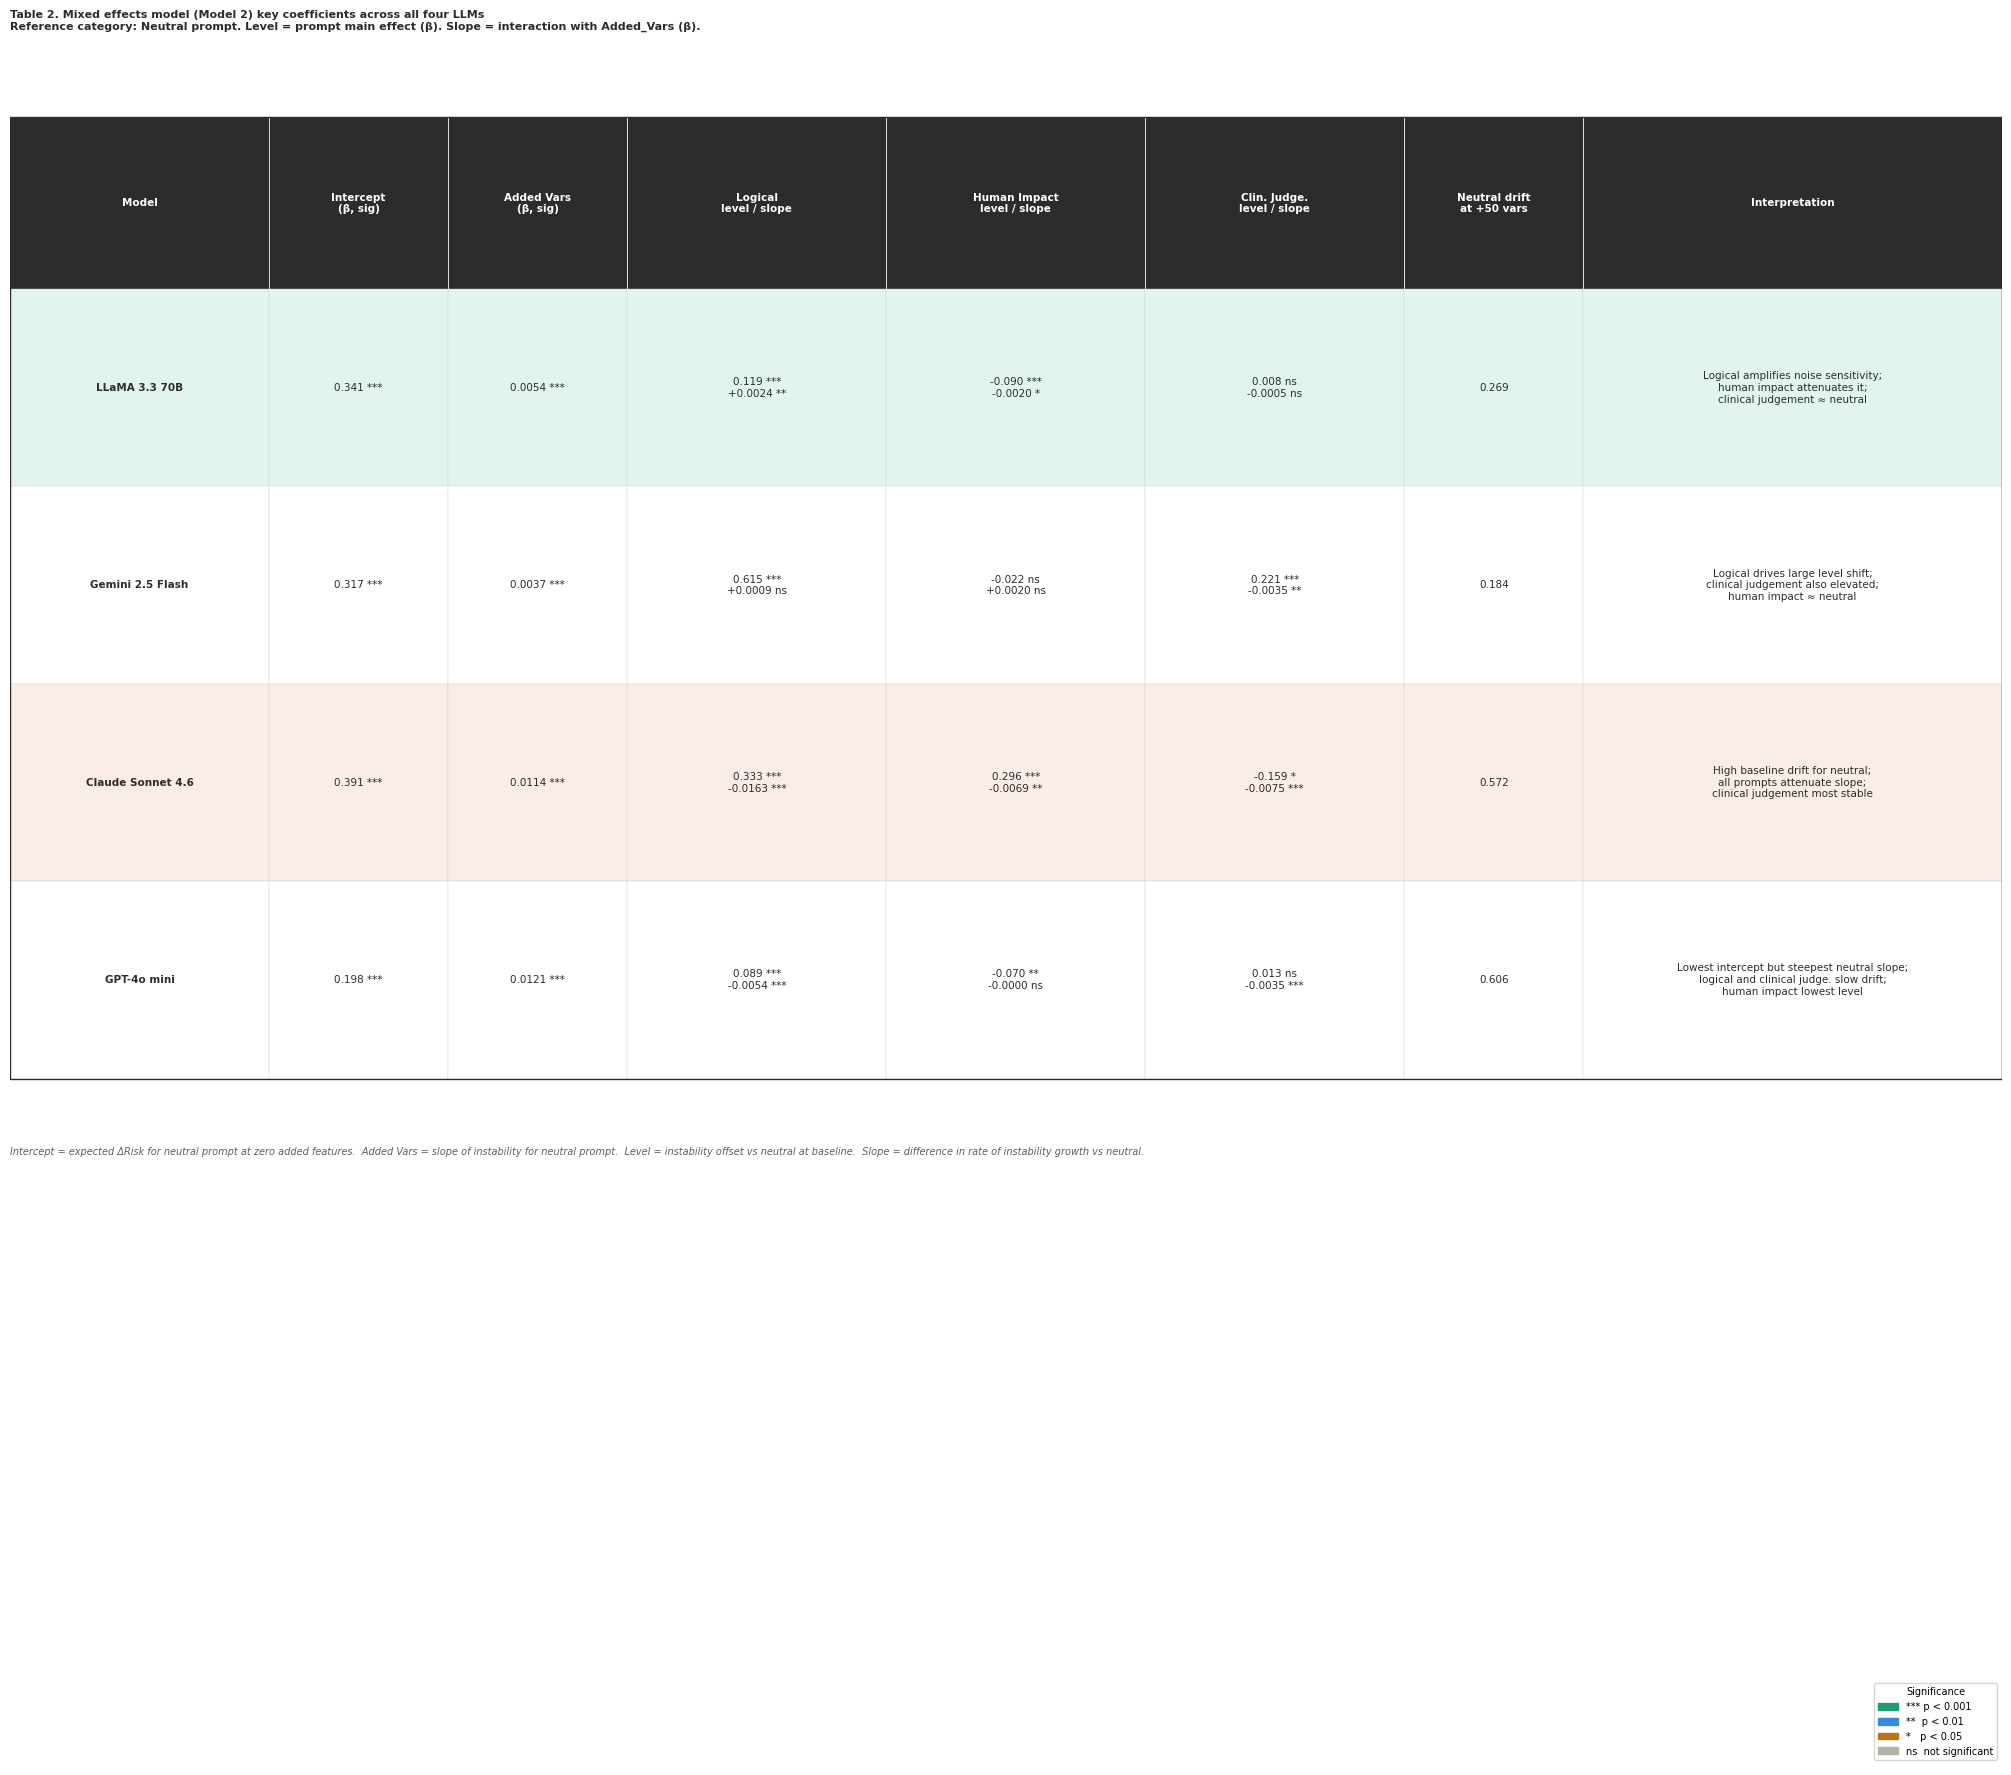

Saved: table2_cross_model_mixed_effects.png


In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np


models = ["LLaMA 3.3 70B", "Gemini 2.5 Flash", "Claude Sonnet 4.6", "GPT-4o mini"]

data = {
    "LLaMA 3.3 70B": {
        "Intercept":            ("0.341", "***"),
        "Added_Vars":           ("0.0054", "***"),
        "Logical (level)":      ("0.119", "***"),
        "Logical (slope)":      ("+0.0024", "**"),
        "Human Impact (level)": ("-0.090", "***"),
        "Human Impact (slope)": ("-0.0020", "*"),
        "Clin. Judge. (level)": ("0.008", "ns"),
        "Clin. Judge. (slope)": ("-0.0005", "ns"),
        "Drift +50 (neutral)":  "0.269",
        "Interpretation":       "Logical amplifies noise sensitivity;\nhuman impact attenuates it;\nclinical judgement ≈ neutral",
    },
    "Gemini 2.5 Flash": {
        "Intercept":            ("0.317", "***"),
        "Added_Vars":           ("0.0037", "***"),
        "Logical (level)":      ("0.615", "***"),
        "Logical (slope)":      ("+0.0009", "ns"),
        "Human Impact (level)": ("-0.022", "ns"),
        "Human Impact (slope)": ("+0.0020", "ns"),
        "Clin. Judge. (level)": ("0.221", "***"),
        "Clin. Judge. (slope)": ("-0.0035", "**"),
        "Drift +50 (neutral)":  "0.184",
        "Interpretation":       "Logical drives large level shift;\nclinical judgement also elevated;\nhuman impact ≈ neutral",
    },
    "Claude Sonnet 4.6": {
        "Intercept":            ("0.391", "***"),
        "Added_Vars":           ("0.0114", "***"),
        "Logical (level)":      ("0.333", "***"),
        "Logical (slope)":      ("-0.0163", "***"),
        "Human Impact (level)": ("0.296", "***"),
        "Human Impact (slope)": ("-0.0069", "**"),
        "Clin. Judge. (level)": ("-0.159", "*"),
        "Clin. Judge. (slope)": ("-0.0075", "***"),
        "Drift +50 (neutral)":  "0.572",
        "Interpretation":       "High baseline drift for neutral;\nall prompts attenuate slope;\nclinical judgement most stable",
    },
    "GPT-4o mini": {
        "Intercept":            ("0.198", "***"),
        "Added_Vars":           ("0.0121", "***"),
        "Logical (level)":      ("0.089", "***"),
        "Logical (slope)":      ("-0.0054", "***"),
        "Human Impact (level)": ("-0.070", "**"),
        "Human Impact (slope)": ("-0.0000", "ns"),
        "Clin. Judge. (level)": ("0.013", "ns"),
        "Clin. Judge. (slope)": ("-0.0035", "***"),
        "Drift +50 (neutral)":  "0.606",
        "Interpretation":       "Lowest intercept but steepest neutral slope;\nlogical and clinical judge. slow drift;\nhuman impact lowest level",
    },
}

col_labels = [
    "Model",
    "Intercept\n(β, sig)",
    "Added Vars\n(β, sig)",
    "Logical\nlevel / slope",
    "Human Impact\nlevel / slope",
    "Clin. Judge.\nlevel / slope",
    "Neutral drift\nat +50 vars",
    "Interpretation",
]
col_widths = [0.13, 0.09, 0.09, 0.13, 0.13, 0.13, 0.09, 0.21]

def sig_color(sig):
    return {"***": "#1D9E75", "**": "#378ADD", "*": "#BA7517", "ns": "#B4B2A9"}[sig]

rows = []
for m in models:
    d = data[m]
    rows.append([
        m,
        f"{d['Intercept'][0]} {d['Intercept'][1]}",
        f"{d['Added_Vars'][0]} {d['Added_Vars'][1]}",
        f"{d['Logical (level)'][0]} {d['Logical (level)'][1]}\n{d['Logical (slope)'][0]} {d['Logical (slope)'][1]}",
        f"{d['Human Impact (level)'][0]} {d['Human Impact (level)'][1]}\n{d['Human Impact (slope)'][0]} {d['Human Impact (slope)'][1]}",
        f"{d['Clin. Judge. (level)'][0]} {d['Clin. Judge. (level)'][1]}\n{d['Clin. Judge. (slope)'][0]} {d['Clin. Judge. (slope)'][1]}",
        d["Drift +50 (neutral)"],
        d["Interpretation"],
    ])

n_rows = len(rows)
n_cols = len(col_labels)
row_h   = 0.115
header_h = 0.10
fig_h   = 1.2 + header_h + n_rows * row_h

fig, ax = plt.subplots(figsize=(20, fig_h * 10))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

xs     = np.cumsum([0] + col_widths[:-1])
y_top  = 0.96
total_h = header_h + n_rows * row_h

# ── Header ────────────────────────────────────────────────
for j, (label, x, w) in enumerate(zip(col_labels, xs, col_widths)):
    rect = mpatches.FancyBboxPatch(
        (x, y_top - header_h), w, header_h,
        boxstyle="square,pad=0", linewidth=0.5,
        edgecolor="white", facecolor="#2C2C2A"
    )
    ax.add_patch(rect)
    ax.text(x + w/2, y_top - header_h/2, label,
            ha="center", va="center", fontsize=7.5,
            fontweight="bold", color="white")

# ── Rows ──────────────────────────────────────────────────
model_colors = {
    "LLaMA 3.3 70B":    "#E1F5EE",
    "Gemini 2.5 Flash": "#EEEDFE",
    "Claude Sonnet 4.6":"#FAECE7",
    "GPT-4o mini":      "#E6F1FB",
}

for i, row in enumerate(rows):
    y_row  = y_top - header_h - (i + 1) * row_h
    m_name = row[0]
    bg     = model_colors[m_name] if i % 2 == 0 else "white"

    for j, (val, x, w) in enumerate(zip(row, xs, col_widths)):
        rect = mpatches.FancyBboxPatch(
            (x, y_row), w, row_h,
            boxstyle="square,pad=0", linewidth=0.3,
            edgecolor="#D3D1C7", facecolor=bg
        )
        ax.add_patch(rect)

        fw = "bold" if j == 0 else "normal"
        fs = 7.5
        color = "#2C2C2A"

        ax.text(x + w/2, y_row + row_h/2, str(val),
                ha="center", va="center",
                fontsize=fs, color=color,
                fontweight=fw, multialignment="center")

# ── Outer border ──────────────────────────────────────────
outer = mpatches.FancyBboxPatch(
    (0, y_top - total_h), 1, total_h,
    boxstyle="square,pad=0", linewidth=1,
    edgecolor="#2C2C2A", facecolor="none"
)
ax.add_patch(outer)

# ── Legend ────────────────────────────────────────────────
legend_items = [
    mpatches.Patch(color="#1D9E75", label="*** p < 0.001"),
    mpatches.Patch(color="#378ADD", label="**  p < 0.01"),
    mpatches.Patch(color="#BA7517", label="*   p < 0.05"),
    mpatches.Patch(color="#B4B2A9", label="ns  not significant"),
]
ax.legend(handles=legend_items, loc="lower right",
          fontsize=7, framealpha=0.8, title="Significance", title_fontsize=7)

ax.text(0, 1.01,
        "Mixed effects model (Model 2) key coefficients across all four LLMs\n"
        "Reference category: Neutral prompt. Level = prompt main effect (β). Slope = interaction with Added_Vars (β).",
        ha="left", va="bottom", fontsize=8, fontweight="bold",
        color="#2C2C2A", transform=ax.transAxes)

ax.text(0, y_top - total_h - 0.04,
        "Intercept = expected ΔRisk for neutral prompt at zero added features.  "
        "Added Vars = slope of instability for neutral prompt.  "
        "Level = instability offset vs neutral at baseline.  "
        "Slope = difference in rate of instability growth vs neutral.",
        ha="left", va="top", fontsize=7, color="#5F5E5A",
        style="italic", transform=ax.transAxes)

plt.tight_layout(pad=0.3)
plt.savefig("table2_cross_model_mixed_effects.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: table2_cross_model_mixed_effects.png")

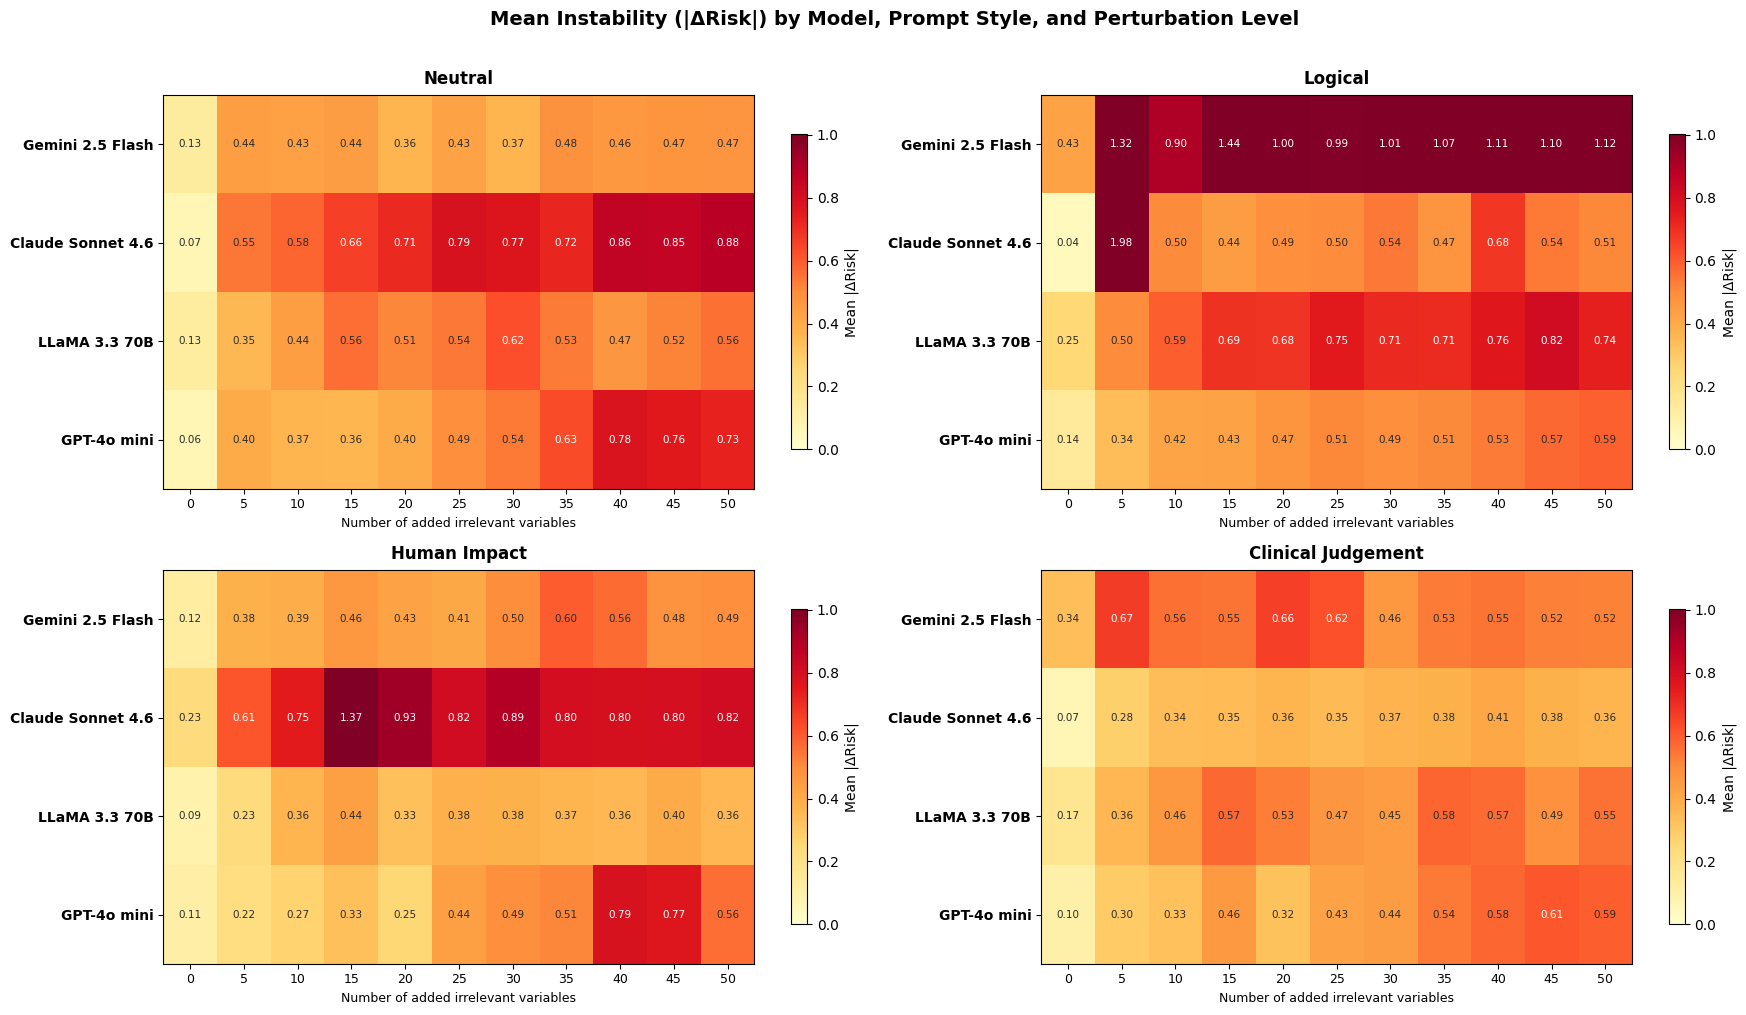

Saved: heatmap_cross_model_instability.png


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os


model_configs = {
    "Gemini 2.5 Flash": {
        "folder": "gemini",   # CHANGE: subfolder name
        "files": {
            "Neutral":            "scores_google_gemini-2.5-flash_neutral.csv",
            "Logical":            "scores_google_gemini-2.5-flash_logical.csv",
            "Human Impact":       "scores_google_gemini-2.5-flash_human_impact.csv",
            "Clinical Judgement": "scores_google_gemini-2.5-flash_clinical_judgement.csv",
        }
    },
    "Claude Sonnet 4.6": {
        "folder": "claude",   # CHANGE: subfolder name
        "files": {
            "Neutral":            "scores_anthropic_claude-sonnet-4.6_neutral.csv",
            "Logical":            "scores_anthropic_claude-sonnet-4.6_logical.csv",
            "Human Impact":       "scores_anthropic_claude-sonnet-4.6_human_impact.csv",
            "Clinical Judgement": "scores_anthropic_claude-sonnet-4.6_clinical_judgement.csv",
        }
    },
    "LLaMA 3.3 70B": {
        "folder": "llama",    # CHANGE: subfolder name
        "files": {
            "Neutral":            "scores_meta-llama_llama-3.3-70b-instruct_neutral.csv",
            "Logical":            "scores_meta-llama_llama-3.3-70b-instruct_logical.csv",
            "Human Impact":       "scores_meta-llama_llama-3.3-70b-instruct_human_impact.csv",
            "Clinical Judgement": "scores_meta-llama_llama-3.3-70b-instruct_clinical_judgement.csv",
        }
    },
    "GPT-4o mini": {
        "folder": "gpt",      # CHANGE: subfolder name
        "files": {
            "Neutral":            "scores_openai_gpt-4o-mini_neutral.csv",
            "Logical":            "scores_openai_gpt-4o-mini_logical.csv",
            "Human Impact":       "scores_openai_gpt-4o-mini_human_impact.csv",
            "Clinical Judgement": "scores_openai_gpt-4o-mini_clinical_judgement.csv",
        }
    },
}

PROMPTS       = ["Neutral", "Logical", "Human Impact", "Clinical Judgement"]
PERTURB_STEPS = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50]

# =========================================================
# Helper: load and compute mean ΔRisk per perturbation level
# =========================================================
def load_mean_delta(folder, filename):
    path = os.path.join(folder, filename)
    df   = pd.read_csv(path)
    baseline_means = (
        df[df["Condition"] == "baseline"]
        .groupby("Patient_ID")["Risk_Score"]
        .mean()
        .rename("Baseline_Risk")
    )
    df = df.merge(baseline_means, on="Patient_ID", how="left")
    df["Abs_Delta_Risk"] = (df["Risk_Score"] - df["Baseline_Risk"]).abs()
    df = df.dropna(subset=["Abs_Delta_Risk", "Added_Vars"])
    return df.groupby("Added_Vars")["Abs_Delta_Risk"].mean()

# =========================================================
# Build matrix: shape (n_models × n_prompts) × n_perturbations
# =========================================================
all_data = {}   # key = (model, prompt), value = Series indexed by Added_Vars

for model_label, config in model_configs.items():
    for prompt, fname in config["files"].items():
        try:
            means = load_mean_delta(config["folder"], fname)
            all_data[(model_label, prompt)] = means
        except FileNotFoundError:
            print(f"  Missing: {config['folder']}/{fname} — filling with NaN")
            all_data[(model_label, prompt)] = pd.Series(
                [np.nan] * len(PERTURB_STEPS), index=PERTURB_STEPS
            )

# =========================================================
# Plot: one heatmap panel per prompt style (2×2 grid)
# =========================================================
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes = axes.flatten()

# shared colour scale across all panels
all_vals = np.concatenate([
    s.reindex(PERTURB_STEPS).values
    for s in all_data.values()
    if not s.isnull().all()
])
vmin = 0
vmax = np.nanpercentile(all_vals, 95)  # clip extreme outliers for colour scale

cmap = "YlOrRd"

for ax, prompt in zip(axes, PROMPTS):
    matrix = np.array([
        all_data[(m, prompt)].reindex(PERTURB_STEPS).values
        for m in model_configs.keys()
    ])

    im = ax.imshow(
        matrix, aspect="auto", cmap=cmap,
        vmin=vmin, vmax=vmax,
        interpolation="nearest"
    )

    ax.set_xticks(range(len(PERTURB_STEPS)))
    ax.set_xticklabels(PERTURB_STEPS, fontsize=9)
    ax.set_yticks(range(len(model_configs)))
    ax.set_yticklabels(list(model_configs.keys()), fontsize=10, fontweight="bold")
    ax.set_xlabel("Number of added irrelevant variables", fontsize=9)
    ax.set_title(prompt, fontsize=12, fontweight="bold", pad=8)

    # annotate cells with values
    for i in range(len(model_configs)):
        for j in range(len(PERTURB_STEPS)):
            val = matrix[i, j]
            if not np.isnan(val):
                text_color = "white" if val > vmax * 0.6 else "#2C2C2A"
                ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                        fontsize=7.5, color=text_color)

    plt.colorbar(im, ax=ax, label="Mean |ΔRisk|", shrink=0.8)

fig.suptitle(
    "Mean Instability (|ΔRisk|) by Model, Prompt Style, and Perturbation Level",
    fontsize=14, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.savefig("heatmap_cross_model_instability.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: heatmap_cross_model_instability.png")

  Missing: gpt/scores_openai_gpt-4o-mini_neutral.csv — skipping
  Missing: gpt/scores_openai_gpt-4o-mini_logical.csv — skipping
  Missing: gpt/scores_openai_gpt-4o-mini_human_impact.csv — skipping
  Missing: gpt/scores_openai_gpt-4o-mini_clinical_judgement.csv — skipping


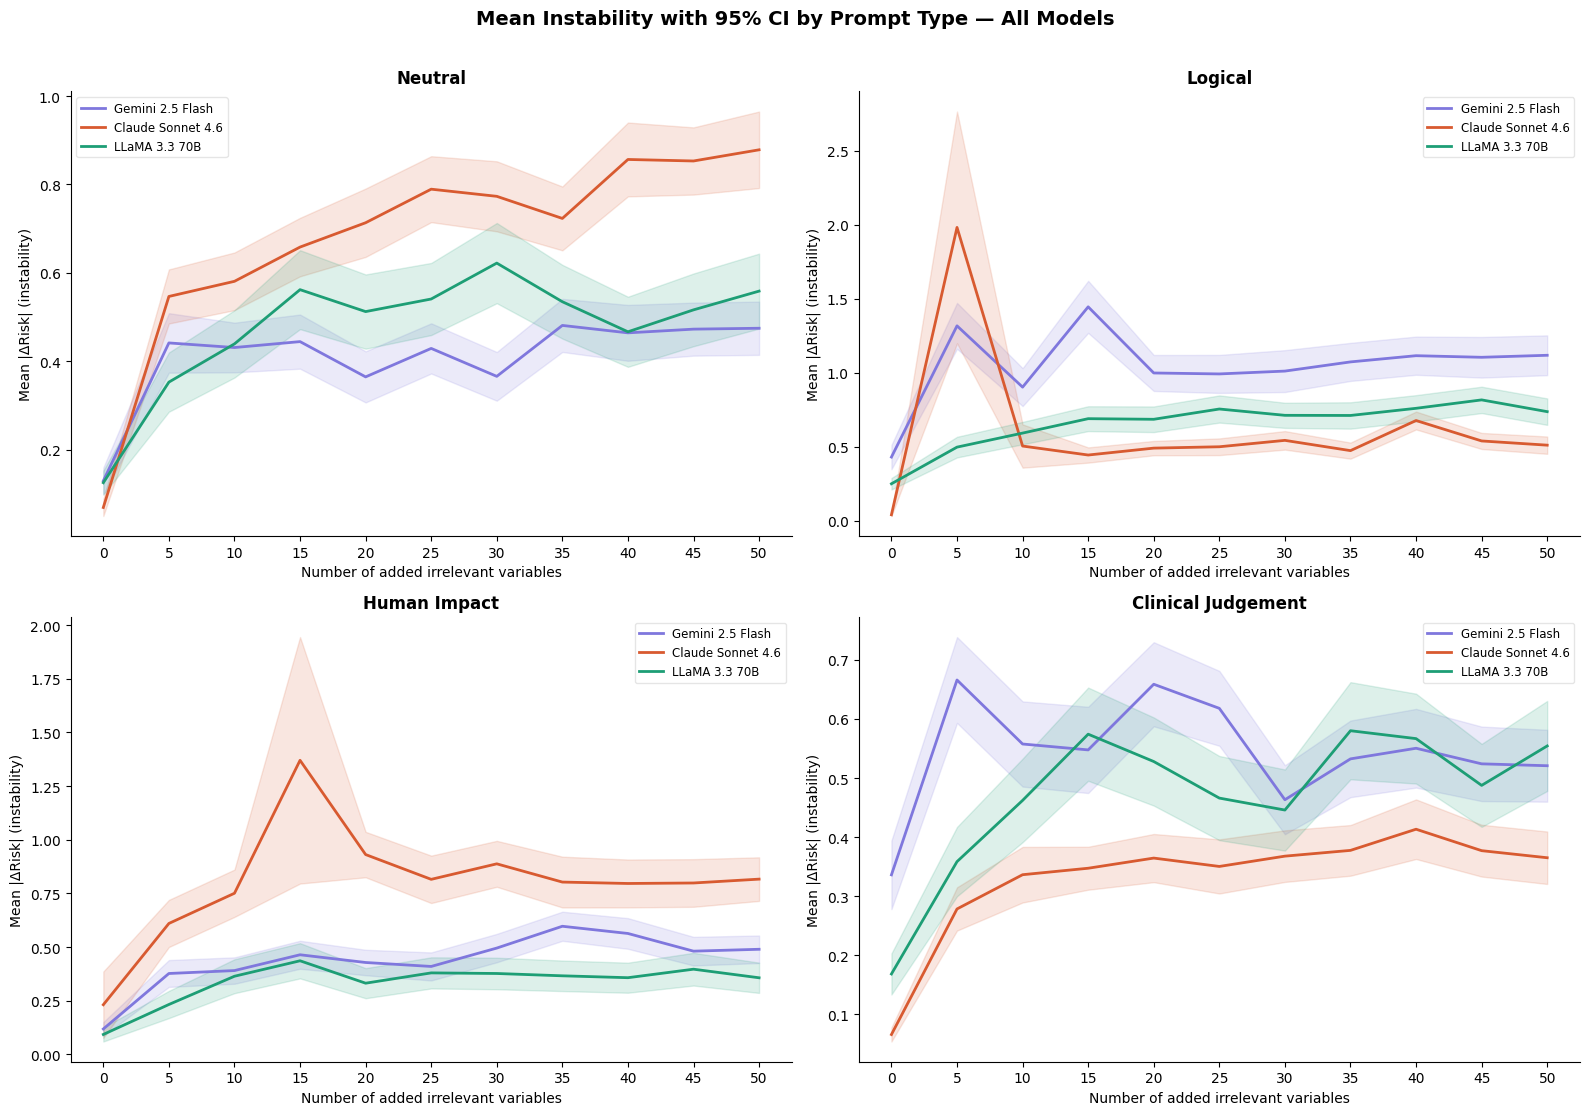

Saved: ci_crossmodel_by_prompt.png


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import os

# =========================================================
# CHANGE 1: set subfolder names to match your directory
# =========================================================
model_configs = {
    "Gemini 2.5 Flash": {
        "folder": "gemini",
        "color":  "#7F77DD",
        "files": {
            "Neutral":            "scores_google_gemini-2.5-flash_neutral.csv",
            "Logical":            "scores_google_gemini-2.5-flash_logical.csv",
            "Human Impact":       "scores_google_gemini-2.5-flash_human_impact.csv",
            "Clinical Judgement": "scores_google_gemini-2.5-flash_clinical_judgement.csv",
        }
    },
    "Claude Sonnet 4.6": {
        "folder": "claude",
        "color":  "#D85A30",
        "files": {
            "Neutral":            "scores_anthropic_claude-sonnet-4.6_neutral.csv",
            "Logical":            "scores_anthropic_claude-sonnet-4.6_logical.csv",
            "Human Impact":       "scores_anthropic_claude-sonnet-4.6_human_impact.csv",
            "Clinical Judgement": "scores_anthropic_claude-sonnet-4.6_clinical_judgement.csv",
        }
    },
    "LLaMA 3.3 70B": {
        "folder": "llama",
        "color":  "#1D9E75",
        "files": {
            "Neutral":            "scores_meta-llama_llama-3.3-70b-instruct_neutral.csv",
            "Logical":            "scores_meta-llama_llama-3.3-70b-instruct_logical.csv",
            "Human Impact":       "scores_meta-llama_llama-3.3-70b-instruct_human_impact.csv",
            "Clinical Judgement": "scores_meta-llama_llama-3.3-70b-instruct_clinical_judgement.csv",
        }
    },
    "GPT-4o mini": {
        "folder": "gpt",
        "color":  "#BA7517",
        "files": {
            "Neutral":            "scores_openai_gpt-4o-mini_neutral.csv",
            "Logical":            "scores_openai_gpt-4o-mini_logical.csv",
            "Human Impact":       "scores_openai_gpt-4o-mini_human_impact.csv",
            "Clinical Judgement": "scores_openai_gpt-4o-mini_clinical_judgement.csv",
        }
    },
}

PROMPTS = ["Neutral", "Logical", "Human Impact", "Clinical Judgement"]

# =========================================================
# Helper: load and compute mean ΔRisk + 95% CI per Added_Vars
# =========================================================
def load_ci(folder, filename):
    path = os.path.join(folder, filename)
    df   = pd.read_csv(path)
    baseline_means = (
        df[df["Condition"] == "baseline"]
        .groupby("Patient_ID")["Risk_Score"]
        .mean()
        .rename("Baseline_Risk")
    )
    df = df.merge(baseline_means, on="Patient_ID", how="left")
    df["Abs_Delta_Risk"] = (df["Risk_Score"] - df["Baseline_Risk"]).abs()
    df = df.dropna(subset=["Abs_Delta_Risk", "Added_Vars"])

    grouped = df.groupby("Added_Vars")["Abs_Delta_Risk"]
    means   = grouped.mean()
    sems    = grouped.sem()
    ns      = grouped.count()
    ci      = sems * stats.t.ppf(0.975, df=ns - 1)

    return means, ci

# =========================================================
# 2×2 grid — one panel per prompt, all models overlaid
# =========================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 11), sharey=False)
axes = axes.flatten()

for ax, prompt in zip(axes, PROMPTS):
    for model_label, config in model_configs.items():
        fname = config["files"][prompt]
        color = config["color"]
        try:
            means, ci = load_ci(config["folder"], fname)
            x = means.index
            ax.plot(x, means, label=model_label, color=color, linewidth=2)
            ax.fill_between(x, means - ci, means + ci, alpha=0.15, color=color)
        except FileNotFoundError:
            print(f"  Missing: {config['folder']}/{fname} — skipping")

    ax.set_title(prompt, fontsize=12, fontweight="bold")
    ax.set_xlabel("Number of added irrelevant variables", fontsize=10)
    ax.set_ylabel("Mean |ΔRisk| (instability)", fontsize=10)
    ax.set_xticks([0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50])
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(fontsize=8.5, framealpha=0.5)

fig.suptitle(
    "Mean Instability with 95% CI by Prompt Type — All Models",
    fontsize=14, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.savefig("ci_crossmodel_by_prompt.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: ci_crossmodel_by_prompt.png")

  Missing: gpt/scores_openai_gpt-4o-mini_neutral.csv — skipping
  Missing: gpt/scores_openai_gpt-4o-mini_logical.csv — skipping
  Missing: gpt/scores_openai_gpt-4o-mini_human_impact.csv — skipping
  Missing: gpt/scores_openai_gpt-4o-mini_clinical_judgement.csv — skipping


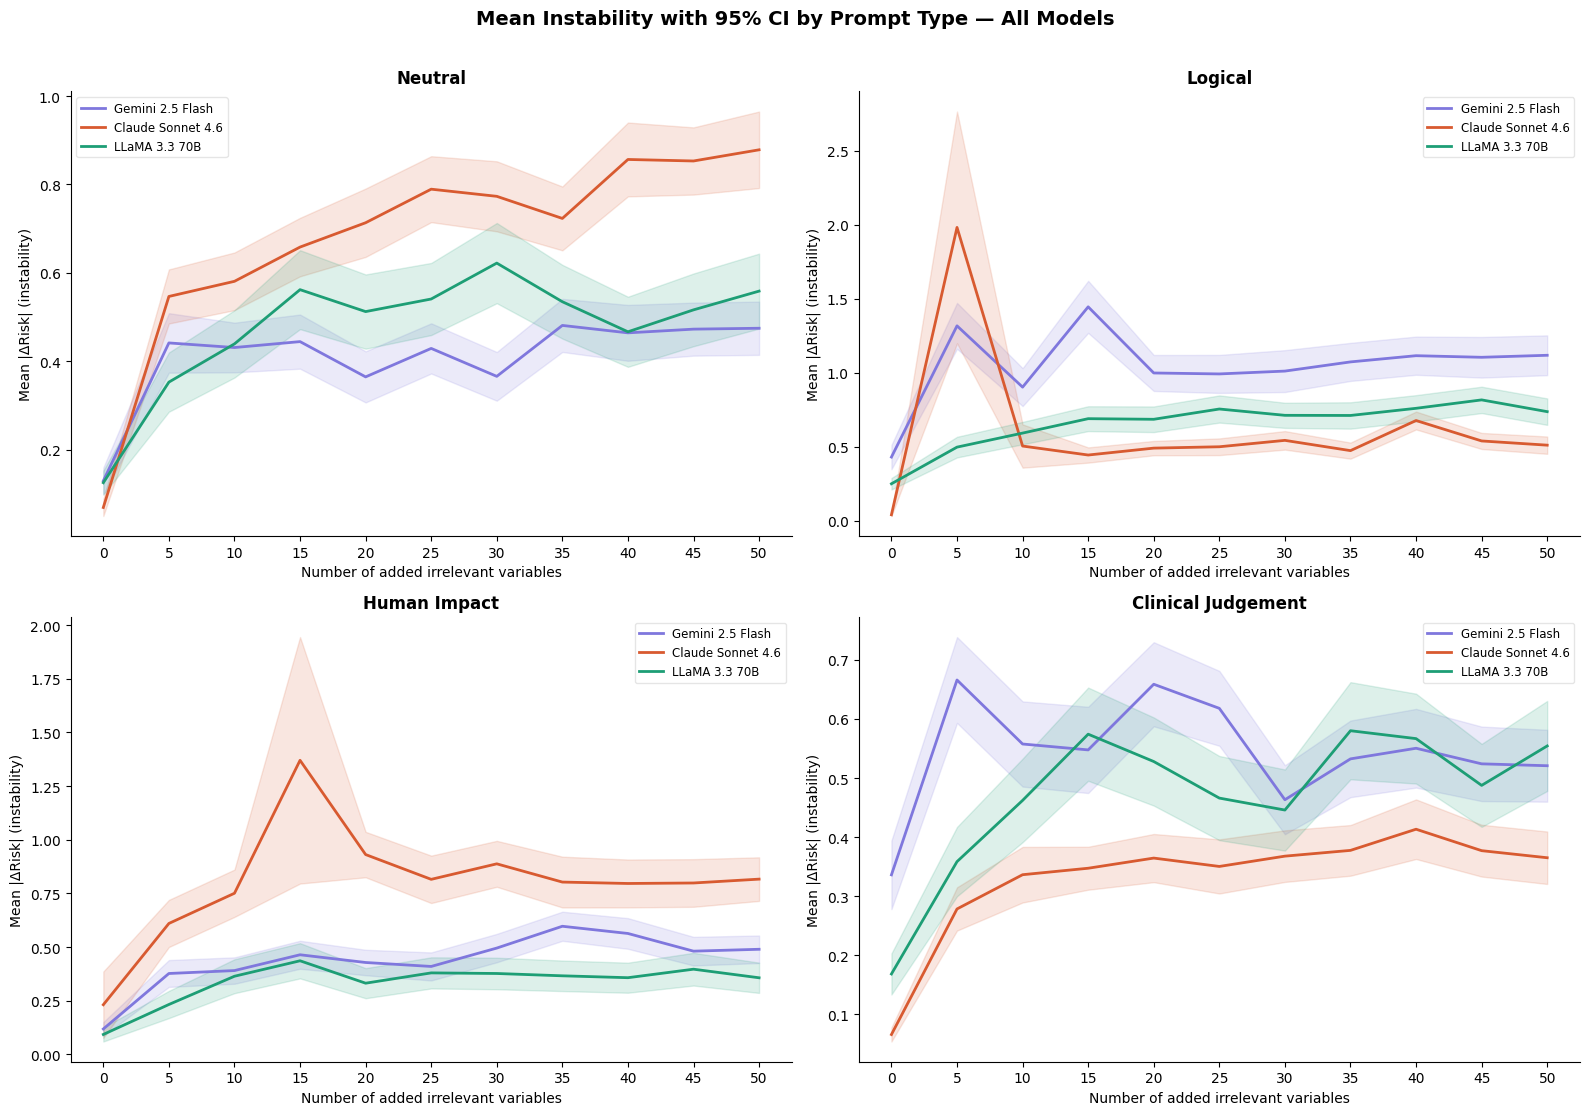

Saved: ci_crossmodel_by_prompt.png


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import os

# =========================================================
# CHANGE 1: set subfolder names to match your directory
# =========================================================
model_configs = {
    "Gemini 2.5 Flash": {
        "folder": "gemini",
        "color":  "#7F77DD",
        "files": {
            "Neutral":            "scores_google_gemini-2.5-flash_neutral.csv",
            "Logical":            "scores_google_gemini-2.5-flash_logical.csv",
            "Human Impact":       "scores_google_gemini-2.5-flash_human_impact.csv",
            "Clinical Judgement": "scores_google_gemini-2.5-flash_clinical_judgement.csv",
        }
    },
    "Claude Sonnet 4.6": {
        "folder": "claude",
        "color":  "#D85A30",
        "files": {
            "Neutral":            "scores_anthropic_claude-sonnet-4.6_neutral.csv",
            "Logical":            "scores_anthropic_claude-sonnet-4.6_logical.csv",
            "Human Impact":       "scores_anthropic_claude-sonnet-4.6_human_impact.csv",
            "Clinical Judgement": "scores_anthropic_claude-sonnet-4.6_clinical_judgement.csv",
        }
    },
    "LLaMA 3.3 70B": {
        "folder": "llama",
        "color":  "#1D9E75",
        "files": {
            "Neutral":            "scores_meta-llama_llama-3.3-70b-instruct_neutral.csv",
            "Logical":            "scores_meta-llama_llama-3.3-70b-instruct_logical.csv",
            "Human Impact":       "scores_meta-llama_llama-3.3-70b-instruct_human_impact.csv",
            "Clinical Judgement": "scores_meta-llama_llama-3.3-70b-instruct_clinical_judgement.csv",
        }
    },
    "GPT-4o mini": {
        "folder": "gpt",
        "color":  "#BA7517",
        "files": {
            "Neutral":            "scores_openai_gpt-4o-mini_neutral.csv",
            "Logical":            "scores_openai_gpt-4o-mini_logical.csv",
            "Human Impact":       "scores_openai_gpt-4o-mini_human_impact.csv",
            "Clinical Judgement": "scores_openai_gpt-4o-mini_clinical_judgement.csv",
        }
    },
}

PROMPTS = ["Neutral", "Logical", "Human Impact", "Clinical Judgement"]

# =========================================================
# Helper: load and compute mean ΔRisk + 95% CI per Added_Vars
# =========================================================
def load_ci(folder, filename):
    path = os.path.join(folder, filename)
    df   = pd.read_csv(path)
    baseline_means = (
        df[df["Condition"] == "baseline"]
        .groupby("Patient_ID")["Risk_Score"]
        .mean()
        .rename("Baseline_Risk")
    )
    df = df.merge(baseline_means, on="Patient_ID", how="left")
    df["Abs_Delta_Risk"] = (df["Risk_Score"] - df["Baseline_Risk"]).abs()
    df = df.dropna(subset=["Abs_Delta_Risk", "Added_Vars"])

    grouped = df.groupby("Added_Vars")["Abs_Delta_Risk"]
    means   = grouped.mean()
    sems    = grouped.sem()
    ns      = grouped.count()
    ci      = sems * stats.t.ppf(0.975, df=ns - 1)

    return means, ci

# =========================================================
# 2×2 grid — one panel per prompt, all models overlaid
# =========================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 11), sharey=False)
axes = axes.flatten()

for ax, prompt in zip(axes, PROMPTS):
    for model_label, config in model_configs.items():
        fname = config["files"][prompt]
        color = config["color"]
        try:
            means, ci = load_ci(config["folder"], fname)
            x = means.index
            ax.plot(x, means, label=model_label, color=color, linewidth=2)
            ax.fill_between(x, means - ci, means + ci, alpha=0.15, color=color)
        except FileNotFoundError:
            print(f"  Missing: {config['folder']}/{fname} — skipping")

    ax.set_title(prompt, fontsize=12, fontweight="bold")
    ax.set_xlabel("Number of added irrelevant variables", fontsize=10)
    ax.set_ylabel("Mean |ΔRisk| (instability)", fontsize=10)
    ax.set_xticks([0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50])
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(fontsize=8.5, framealpha=0.5)

fig.suptitle(
    "Mean Instability with 95% CI by Prompt Type — All Models",
    fontsize=14, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.savefig("ci_crossmodel_by_prompt.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: ci_crossmodel_by_prompt.png")

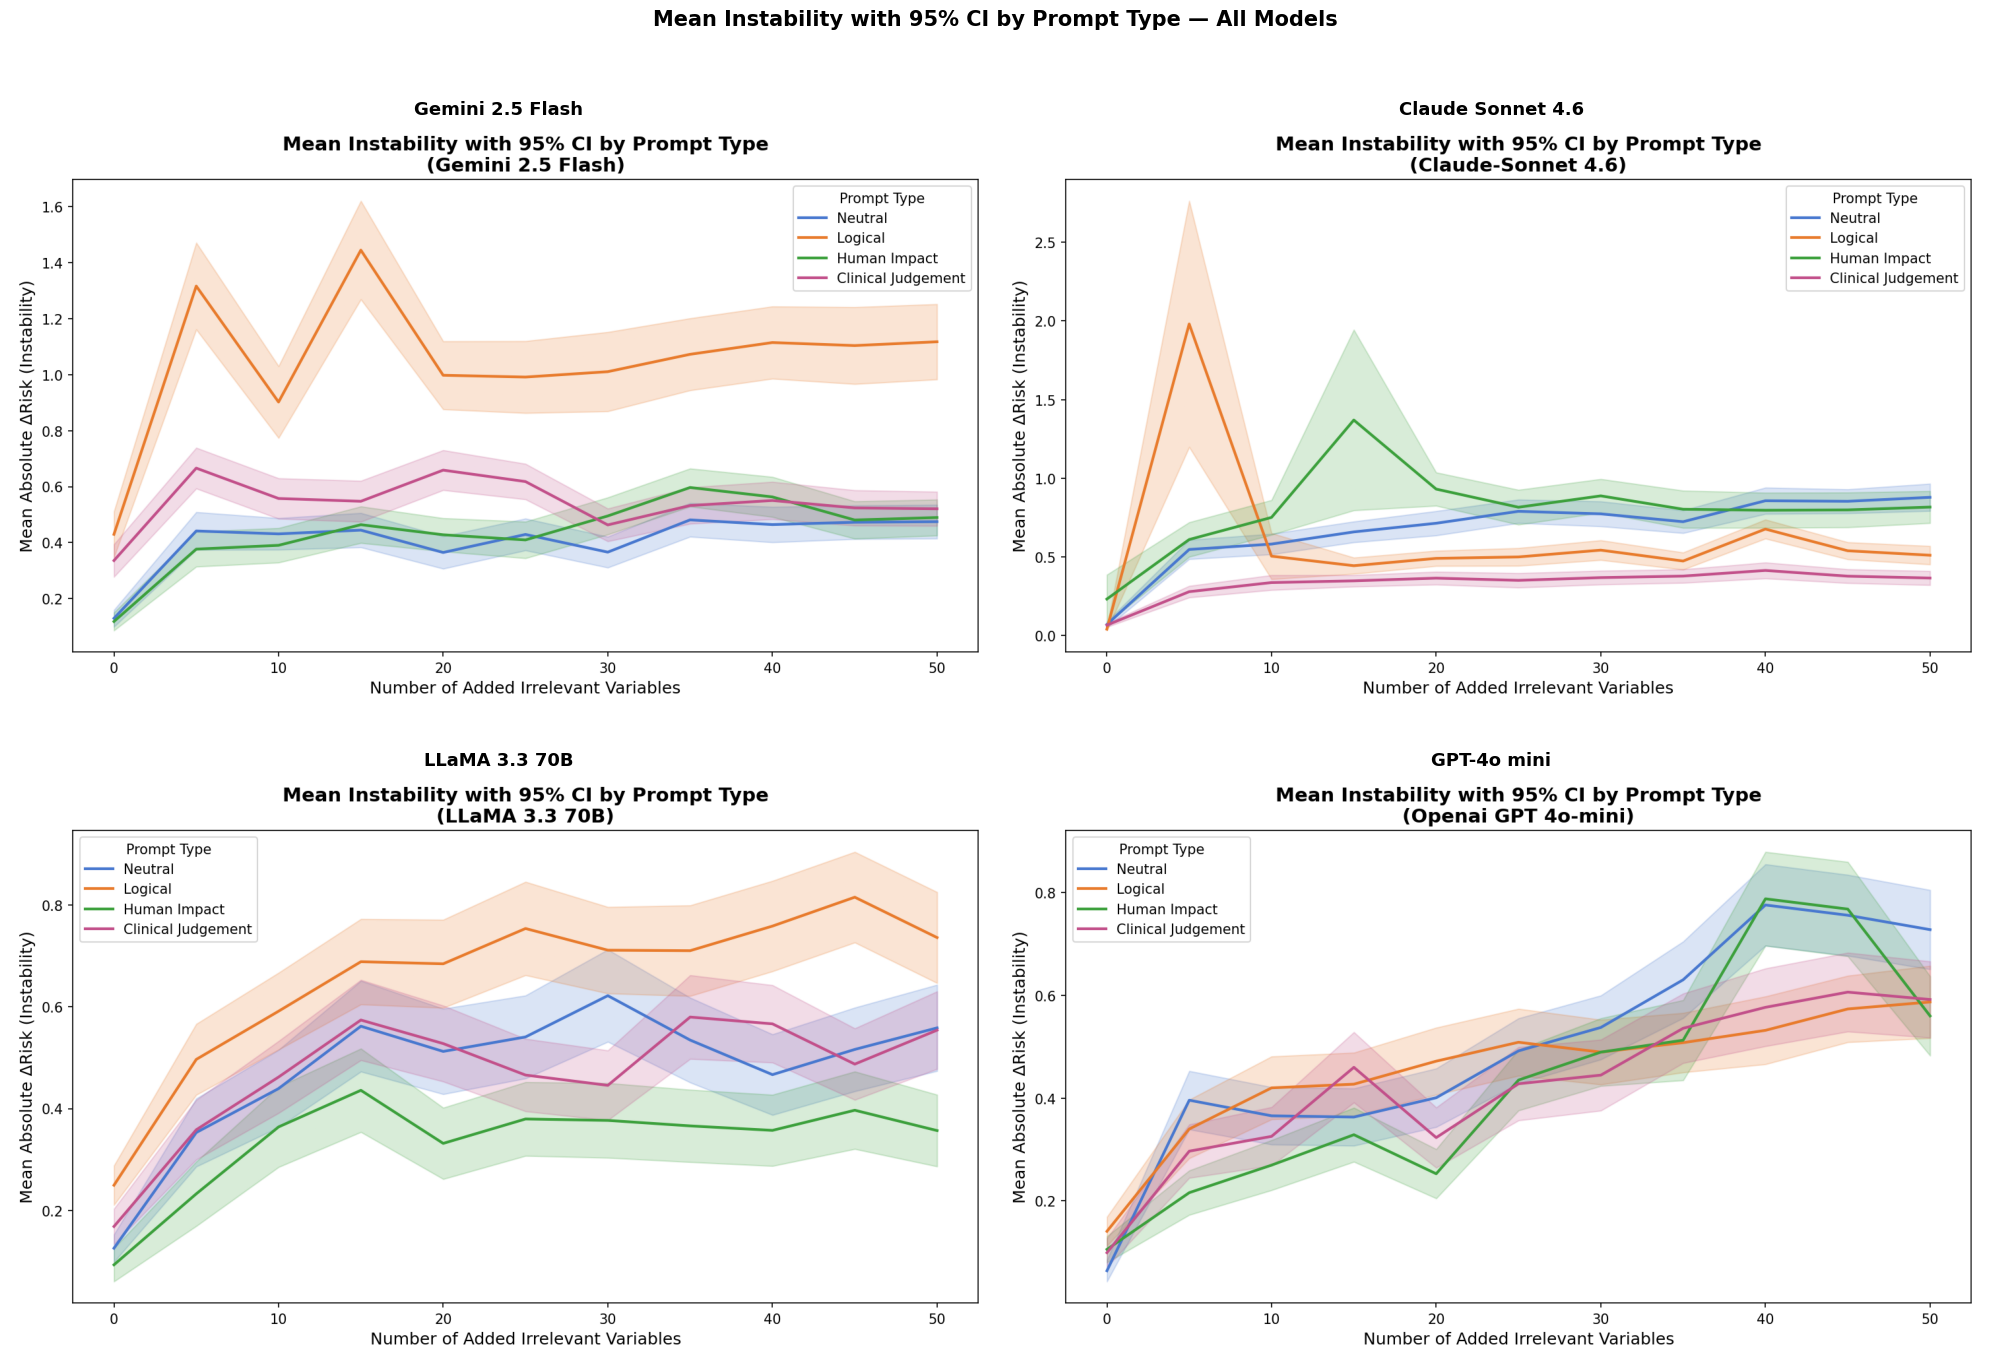

Saved: ci_2x2_all_models.png


In [8]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# =========================================================
# CHANGE: update paths to match your saved CI plot filenames
# =========================================================
plots = {
    "Gemini 2.5 Flash":  "gemini/ci_instability_by_prompt_gemini.png",
    "Claude Sonnet 4.6": "claude/ci_instability_by_prompt_claude.png",
    "LLaMA 3.3 70B":     "llama/ci_instability_by_prompt_llama.png",
    "GPT-4o mini":       "gpt/ci_instability_by_prompt_gpt.png",
}

fig, axes = plt.subplots(2, 2, figsize=(20, 14))
axes = axes.flatten()

for ax, (label, path) in zip(axes, plots.items()):
    img = mpimg.imread(path)
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(label, fontsize=13, fontweight="bold", pad=8)

fig.suptitle(
    "Mean Instability with 95% CI by Prompt Type — All Models",
    fontsize=15, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.savefig("ci_2x2_all_models.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: ci_2x2_all_models.png")

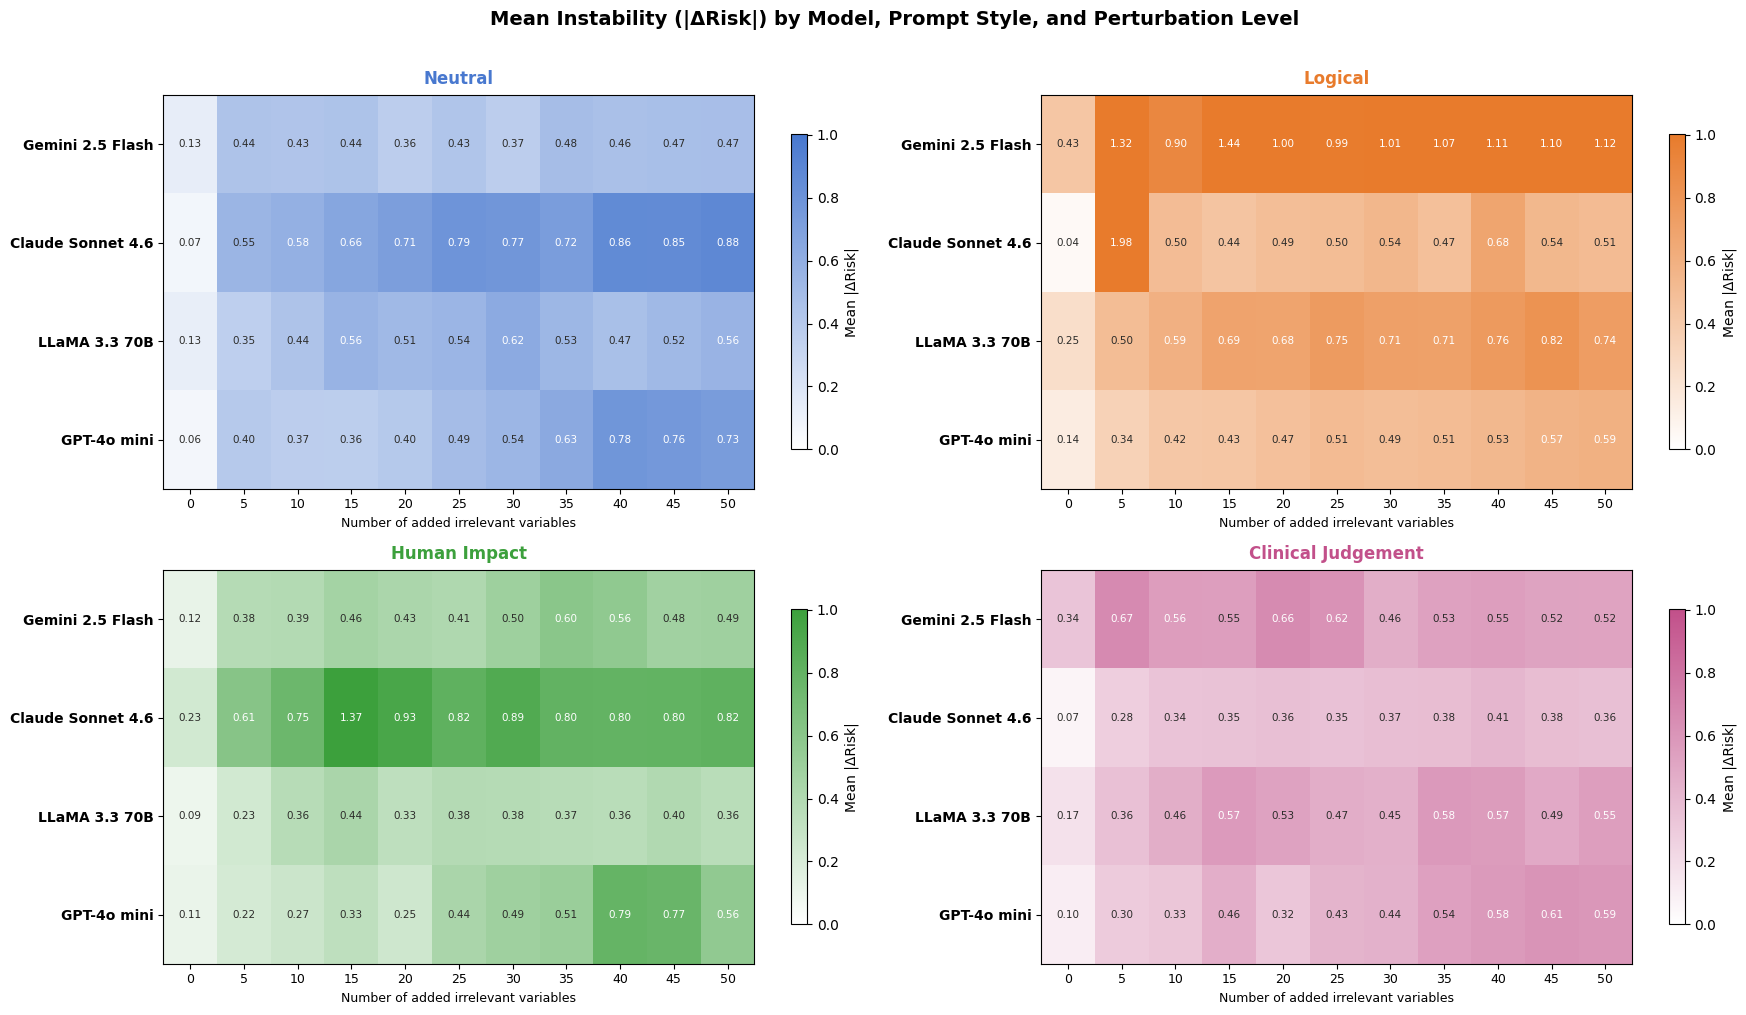

Saved: heatmap_cross_model_instability.png


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os

model_configs = {
    "Gemini 2.5 Flash": {
        "folder": "gemini",
        "files": {
            "Neutral":            "scores_google_gemini-2.5-flash_neutral.csv",
            "Logical":            "scores_google_gemini-2.5-flash_logical.csv",
            "Human Impact":       "scores_google_gemini-2.5-flash_human_impact.csv",
            "Clinical Judgement": "scores_google_gemini-2.5-flash_clinical_judgement.csv",
        }
    },
    "Claude Sonnet 4.6": {
        "folder": "claude",
        "files": {
            "Neutral":            "scores_anthropic_claude-sonnet-4.6_neutral.csv",
            "Logical":            "scores_anthropic_claude-sonnet-4.6_logical.csv",
            "Human Impact":       "scores_anthropic_claude-sonnet-4.6_human_impact.csv",
            "Clinical Judgement": "scores_anthropic_claude-sonnet-4.6_clinical_judgement.csv",
        }
    },
    "LLaMA 3.3 70B": {
        "folder": "llama",
        "files": {
            "Neutral":            "scores_meta-llama_llama-3.3-70b-instruct_neutral.csv",
            "Logical":            "scores_meta-llama_llama-3.3-70b-instruct_logical.csv",
            "Human Impact":       "scores_meta-llama_llama-3.3-70b-instruct_human_impact.csv",
            "Clinical Judgement": "scores_meta-llama_llama-3.3-70b-instruct_clinical_judgement.csv",
        }
    },
    "GPT-4o mini": {
        "folder": "gpt",
        "files": {
            "Neutral":            "scores_openai_gpt-4o-mini_neutral.csv",
            "Logical":            "scores_openai_gpt-4o-mini_logical.csv",
            "Human Impact":       "scores_openai_gpt-4o-mini_human_impact.csv",
            "Clinical Judgement": "scores_openai_gpt-4o-mini_clinical_judgement.csv",
        }
    },
}

PROMPTS       = ["Neutral", "Logical", "Human Impact", "Clinical Judgement"]
PERTURB_STEPS = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50]

# =========================================================
# Per-prompt colours — white to prompt colour
# =========================================================
prompt_colors = {
    "Neutral":            "#4878CF",
    "Logical":            "#E87B2C",
    "Human Impact":       "#3CA03C",
    "Clinical Judgement": "#C2508A",
}

def make_cmap(hex_color):
    return mcolors.LinearSegmentedColormap.from_list(
        "custom", ["#FFFFFF", hex_color]
    )

# =========================================================
# Helper: load mean ΔRisk
# =========================================================
def load_mean_delta(folder, filename):
    path = os.path.join(folder, filename)
    df   = pd.read_csv(path)
    baseline_means = (
        df[df["Condition"] == "baseline"]
        .groupby("Patient_ID")["Risk_Score"]
        .mean()
        .rename("Baseline_Risk")
    )
    df = df.merge(baseline_means, on="Patient_ID", how="left")
    df["Abs_Delta_Risk"] = (df["Risk_Score"] - df["Baseline_Risk"]).abs()
    df = df.dropna(subset=["Abs_Delta_Risk", "Added_Vars"])
    return df.groupby("Added_Vars")["Abs_Delta_Risk"].mean()

# =========================================================
# Build data
# =========================================================
all_data = {}
for model_label, config in model_configs.items():
    for prompt, fname in config["files"].items():
        try:
            all_data[(model_label, prompt)] = load_mean_delta(config["folder"], fname)
        except FileNotFoundError:
            print(f"  Missing: {config['folder']}/{fname} — filling with NaN")
            all_data[(model_label, prompt)] = pd.Series(
                [np.nan] * len(PERTURB_STEPS), index=PERTURB_STEPS
            )

# shared vmax across all panels (95th percentile to clip outliers)
all_vals = np.concatenate([
    s.reindex(PERTURB_STEPS).values
    for s in all_data.values()
    if not s.isnull().all()
])
vmin = 0
vmax = np.nanpercentile(all_vals, 95)

# =========================================================
# Plot
# =========================================================
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes = axes.flatten()

for ax, prompt in zip(axes, PROMPTS):
    cmap = make_cmap(prompt_colors[prompt])

    matrix = np.array([
        all_data[(m, prompt)].reindex(PERTURB_STEPS).values
        for m in model_configs.keys()
    ])

    im = ax.imshow(
        matrix, aspect="auto", cmap=cmap,
        vmin=vmin, vmax=vmax,
        interpolation="nearest"
    )

    ax.set_xticks(range(len(PERTURB_STEPS)))
    ax.set_xticklabels(PERTURB_STEPS, fontsize=9)
    ax.set_yticks(range(len(model_configs)))
    ax.set_yticklabels(list(model_configs.keys()), fontsize=10, fontweight="bold")
    ax.set_xlabel("Number of added irrelevant variables", fontsize=9)
    ax.set_title(prompt, fontsize=12, fontweight="bold", pad=8,
                 color=prompt_colors[prompt])

    for i in range(len(model_configs)):
        for j in range(len(PERTURB_STEPS)):
            val = matrix[i, j]
            if not np.isnan(val):
                text_color = "white" if val > vmax * 0.55 else "#2C2C2A"
                ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                        fontsize=7.5, color=text_color)

    plt.colorbar(im, ax=ax, label="Mean |ΔRisk|", shrink=0.8)

fig.suptitle(
    "Mean Instability (|ΔRisk|) by Model, Prompt Style, and Perturbation Level",
    fontsize=14, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.savefig("heatmap_cross_model_instability.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: heatmap_cross_model_instability.png")